<a href="https://colab.research.google.com/github/niramol489-creator/Project-group13/blob/main/Project_group13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1.นำเข้า ไลบรารี (Libraries) ที่จำเป็นสำหรับการทำงาน
import random      # ใช้สำหรับสุ่มข้อมูล/จำลองข้อมูลตัวเลขและตัวเลือก
import sqlite3     # ใช้เชื่อมต่อและจัดการฐานข้อมูล SQLite ( relational database )
import pandas as pd  # ใช้จัดการ จัดกลุ่ม และวิเคราะห์ข้อมูลในรูปแบบตาราง (DataFrame)
import matplotlib.pyplot as plt  # ใช้สำหรับสร้างกราฟและแผนภูมิสรุปผลข้อมูล (Data Visualization)

# นำเข้าฟังก์ชันจัดการ วันและเวลา
from datetime import datetime, timedelta  # datetime: ใช้ระบุวันที่/เวลา, timedelta: ใช้คำนวณบวกลบระยะเวลา

# แสดงข้อความแจ้งเตือนเมื่อโหลดไลบรารีทั้งหมดเรียบร้อยแล้ว
print("Import Library สำเร็จ")

Import Library สำเร็จ


In [2]:
# 2. สร้าง Class Customer สำหรับเป็นโครงสร้าง/พิมพ์เขียวของข้อมูลลูกค้า
class Customer:

    # เมธอด __init__ (Constructor): ทำหน้าที่รับค่าและกำหนดคุณลักษณะเริ่มต้น (Attributes) ของลูกค้าแต่ละคน
    def __init__(self, customer_id, name, phone):
        self.customer_id = customer_id  # เก็บ รหัสลูกค้า
        self.name = name                # เก็บ ชื่อลูกค้า
        self.phone = phone              # เก็บ เบอร์โทรศัพท์

    # เมธอด get_info: ทำหน้าที่ดึงข้อมูลลูกค้านำออกมาใช้งานในรูปแบบ Dictionary
    def get_info(self):
        return {
            "customer_id": self.customer_id,
            "customer_name": self.name,
            "phone": self.phone
        }

# แสดงข้อความยืนยันในคอนโซลว่าสร้างคลาส Customer เรียบร้อยแล้ว (ใช้เช็กสถานะการทำงาน)
print("สร้าง Class Customer สำเร็จ")

สร้าง Class Customer สำเร็จ


In [3]:
# 3. สร้าง Class Court สำหรับเป็นโครงสร้าง/พิมพ์เขียวของข้อมูลสนามแข่งขัน
class Court:

    # เมธอด __init__ (Constructor): ทำหน้าที่รับค่าและกำหนดคุณลักษณะเริ่มต้น (Attributes) ของแต่ละสนาม
    def __init__(
        self,
        court_id,        # รหัสสนาม
        court_name,      # ชื่อสนาม
        sport_type,      # ประเภทกีฬา (เช่น แบดมินตัน, ฟุตซอล)
        price_per_hour   # ราคาเช่าต่อชั่วโมง
    ):

        self.court_id = court_id
        self.court_name = court_name
        self.sport_type = sport_type
        self.price_per_hour = price_per_hour

    # เมธอด calculate_price: คำนวณราคาสรุปตามจำนวนชั่วโมงที่ระบุใช้งาน
    def calculate_price(self, hours):

        return self.price_per_hour * hours

    # เมธอด get_info: รวบรวมข้อมูลทั้งหมดของสนามส่งกลับออกไปในรูปแบบ Dictionary
    def get_info(self):

        return {
            "court_id": self.court_id,
            "court_name": self.court_name,
            "sport_type": self.sport_type,
            "price_per_hour": self.price_per_hour
        }


# แสดงข้อความยืนยันในคอนโซลว่าสร้างคลาส Court เรียบร้อยแล้ว (ใช้เช็กสถานะการทำงาน)
print("สร้าง Class Court สำเร็จ")

สร้าง Class Court สำเร็จ


In [4]:
#4 สร้าง Class Booking สำหรับเก็บข้อมูลการจองสนามกีฬา
class Booking:

    # __init__ เป็น Constructor
    # ทำงานทันทีเมื่อมีการสร้าง Object Booking
    # รับข้อมูลเกี่ยวกับการจอง ได้แก่ รหัสการจอง ลูกค้า สนาม วันที่ เวลา และจำนวนชั่วโมง
    def __init__(
        self,
        booking_id,      # รหัสการจอง
        customer,        # ข้อมูลลูกค้าที่ทำการจอง
        court,           # ข้อมูลสนามที่ลูกค้าจอง
        booking_date,    # วันที่จอง
        start_time,      # เวลาเริ่มจอง
        hours            # จำนวนชั่วโมงที่จอง
    ):

        # เก็บข้อมูลที่รับเข้ามาไว้ใน Object
        self.booking_id = booking_id
        self.customer = customer
        self.court = court
        self.booking_date = booking_date
        self.start_time = start_time
        self.hours = hours

        # คำนวณราคาทั้งหมดจากราคาของสนามและจำนวนชั่วโมงที่จอง
        # เรียกใช้ Method calculate_price() จาก Class Court
        self.total_price = court.calculate_price(hours)

    # Method สำหรับดึงข้อมูลการจองทั้งหมด
    def get_info(self):

        # ส่งข้อมูลออกมาในรูปแบบ Dictionary
        # ทำให้สามารถนำข้อมูลไปแสดงผลหรือใช้งานต่อได้ง่าย
        return {

            # ข้อมูลการจอง
            "booking_id": self.booking_id,

            # ข้อมูลลูกค้า
            "customer_id":
                self.customer.customer_id,

            "customer_name":
                self.customer.name,

            "phone":
                self.customer.phone,

            # ข้อมูลสนาม
            "court_id":
                self.court.court_id,

            "court_name":
                self.court.court_name,

            "sport_type":
                self.court.sport_type,

            # รายละเอียดการจอง
            "booking_date":
                self.booking_date,

            "start_time":
                self.start_time,

            "hours":
                self.hours,

            # ราคาต่อชั่วโมงของสนาม
            "price_per_hour":
                self.court.price_per_hour,

            # ราคารวมทั้งหมด
            "total_price":
                self.total_price
        }


# แสดงข้อความเพื่อยืนยันว่า Class Booking ถูกสร้างเรียบร้อยแล้ว
print("สร้าง Class Booking สำเร็จ")

สร้าง Class Booking สำเร็จ


In [5]:
#5 คำนวณค่าเช่าสนามที่ลูกค้าต้องจ่ายจริง โดยคิดจากจำนวนชั่วโมงและส่วนลด
def calculate_rental_price(
    price_per_hour,  # ราคาสนามต่อชั่วโมง
    hours,           # จำนวนชั่วโมงที่จอง
    discount=0       # ส่วนลด ถ้าไม่ได้ใส่จะเป็น 0%
):

    # คำนวณราคาทั้งหมดก่อนหักส่วนลด
    total_price = price_per_hour * hours

    # คำนวณว่าได้ส่วนลดเป็นเงินกี่บาท
    discount_amount = (
        total_price * discount / 100
    )

    # เอาราคาทั้งหมดมาหักส่วนลด เพื่อหาราคาที่ต้องจ่ายจริง

    # ส่งราคาสุทธิกลับไปใช้งาน
    return (
        total_price - discount_amount
    )

In [6]:
# 6 ฟังก์ชันสำหรับเช็กว่าสนามว่างหรือไม่
def is_court_available(
    bookings,       # รายการจองทั้งหมดที่มีอยู่
    court_id,       # รหัสสนามที่ต้องการจอง
    booking_date,   # วันที่ต้องการจอง
    start_time,     # เวลาเริ่มจอง
    hours           # จำนวนชั่วโมงที่ต้องการจอง
):

    # แปลงเวลาเริ่มต้นจากข้อความ เช่น "10:00"
    # ให้เป็นข้อมูลวันที่และเวลาที่ Python สามารถนำไปคำนวณได้
    start = datetime.strptime(
        start_time,
        "%H:%M"
    )

    # คำนวณเวลาสิ้นสุดจากเวลาเริ่มต้น + จำนวนชั่วโมงที่จอง
    end = (
        start
        + timedelta(hours=hours)
    )

    # วนดูรายการจองที่มีอยู่ทีละรายการ
    for booking in bookings:

        # เช็กว่าการจองเดิมเป็นสนามเดียวกัน
        # และเป็นวันเดียวกันกับการจองใหม่หรือไม่
        if (
            booking["court_id"] == court_id
            and
            booking["booking_date"] == booking_date
        ):

            # แปลงเวลาเริ่มต้นของการจองเดิม
            # จากข้อความให้เป็นข้อมูลเวลาที่นำไปคำนวณได้
            existing_start = datetime.strptime(
                booking["start_time"],
                "%H:%M"
            )

            # คำนวณเวลาสิ้นสุดของการจองเดิม
            existing_end = (
                existing_start
                + timedelta(
                    hours=booking["hours"]
                )
            )

            # เช็กว่าเวลาที่ต้องการจองใหม่
            # ทับกับช่วงเวลาที่มีคนจองอยู่แล้วหรือไม่
            if (
                start < existing_end
                and
                end > existing_start
            ):

                # ถ้าเวลาทับกัน แปลว่าสนามไม่ว่าง
                return False

    # ถ้าเช็กทุกการจองแล้วไม่มีเวลาไหนทับกัน
    # แปลว่าสนามว่าง
    return True

In [7]:
#7 ฟังก์ชันสำหรับสุ่มวันที่
def random_date(
    start_date,  # วันที่เริ่มต้น
    days=30      # จำนวนวันที่ต้องการสุ่ม ค่าเริ่มต้นคือ 30 วัน
):

    # สุ่มจำนวนวัน ตั้งแต่ 0 ถึงจำนวนวันที่กำหนด
    random_day = random.randint(
        0,
        days
    )

    # นำจำนวนวันที่สุ่มได้ไปบวกกับวันที่เริ่มต้น
    # เพื่อให้ได้วันที่ที่สุ่มขึ้นมา
    date = (
        start_date
        + timedelta(days=random_day)
    )

    # แปลงวันที่ให้อยู่ในรูปแบบ ปี-เดือน-วัน
    # เช่น 2026-08-25
    return date.strftime(
        "%Y-%m-%d"
    )

In [8]:
#8
# สร้างฟังก์ชันชื่อ format_money รับค่าตัวเลขจำนวนเงินผ่านตัวแปร amount
def format_money(amount):

    # คืนค่าข้อความที่จัดฟอร์แมตตัวเลข:
    # :,  -> ใส่เครื่องหมายจุลภาค (comma) คั่นหลักพัน
    # .2f -> แปลงเป็นทศนิยม 2 ตำแหน่ง
    # Baht -> ต่อท้ายด้วยคำว่า Baht
    return f"{amount:,.2f} Baht"

In [9]:
#9
# ============================================================
# FUNCTION แสดงรายละเอียดการจอง
# ============================================================

# สร้างฟังก์ชันแสดงรายละเอียดการจอง รับค่า Dictionary ของการจอง (booking) และเปอร์เซ็นต์ส่วนลด (discount ซึ่งมีค่าเริ่มต้นเป็น 0)
def show_booking_detail(booking, discount=0):

    # --- ดึงข้อมูลจาก Dictionary ที่ชื่อ booking ---
    booking_id = booking["booking_id"]          # รหัสการจอง
    customer_name = booking["customer_name"]    # ชื่อลูกค้า
    court_name = booking["court_name"]          # ชื่อสนาม
    sport_type = booking["sport_type"]          # ประเภทกีฬา
    booking_date = booking["booking_date"]      # วันที่จอง
    start_time = booking["start_time"]          # เวลาเริ่มต้นการใช้งาน
    hours = booking["hours"]                    # จำนวนชั่วโมงที่จอง
    price_per_hour = booking["price_per_hour"]  # ราคาค่าสนามต่อชั่วโมง

    # --- คำนวณเวลาสิ้นสุดการใช้งาน ---
    # แปลงข้อความเวลาเริ่มต้น (เช่น "14:00") ให้เป็นวัตถุ datetime เพื่อใช้คำนวณ
    start = datetime.strptime(
        start_time,
        "%H:%M"
    )

    # บวกจำนวนชั่วโมงที่จองเพิ่มเข้าไปในเวลาเริ่ม
    end = start + timedelta(
        hours=hours
    )

    # แปลงผลลัพธ์เวลากลับมาเป็นข้อความในรูปแบบ HH:MM (เช่น "16:00")
    end_time = end.strftime(
        "%H:%M"
    )

    # --- คำนวณราคาและส่วนลด ---
    # คำนวณราคารวมก่อนหักส่วนลด (ราคาต่อชั่วโมง x จำนวนชั่วโมง)
    before_discount = (
        price_per_hour * hours
    )

    # คำนวณมูลค่าส่วนลด (บาท) จากเปอร์เซ็นต์ส่วนลดที่ได้รับ
    discount_amount = (
        before_discount * discount / 100
    )

    # คำนวณราคาสุทธิที่ต้องจ่ายจริง (ราคาก่อนส่วนลด - มูลค่าส่วนลด)
    final_price = (
        before_discount - discount_amount
    )

    # --- พิมพ์แสดงผลรายละเอียดออกทางหน้าจอ ---
    print("=" * 65)  # พิมพ์เส้นแบ่งยาว 65 ตัวอักษร

    print(
        f"🏟️ การจอง #{booking_id}: "
        f"ลูกค้า '{customer_name}'"
    )

    print(
        f"🏸 สนาม: {court_name}"
    )

    print(
        f"🎯 ประเภทกีฬา: {sport_type}"
    )

    print(
        f"📅 วันที่จอง: {booking_date}"
    )

    print(
        f"⏰ เวลา: {start_time} - {end_time}"
    )

    print(
        f"⏱️ จำนวนชั่วโมง: {hours} ชั่วโมง"
    )

    print("💰 คำนวณราคา:")

    print(
        f"ราคาต่อชั่วโมง = "
        f"{price_per_hour:,.2f} บาท"
    )

    print(
        f"ราคาก่อนส่วนลด = "
        f"{before_discount:,.2f} บาท"
    )

    print(
        f"ส่วนลด = {discount}%"
    )

    print(
        f"💵 ยอดชำระ = "
        f"{final_price:,.2f} บาท"
    )

    print(
        "📋 สถานะ: จองสำเร็จ"
    )

    print("=" * 65)  # พิมพ์เส้นปิดท้าย

In [10]:
#10
# สร้างรายการ (List) ชื่อ courts เก็บวัตถุ (Object) ข้อมูลสนามกีฬาแต่ละแห่ง
courts = [

    # สร้างวัตถุ Court แห่งที่ 1: รหัส "F01", ชื่อ "Football Court 1", ประเภท "Football", ราคา 500 บาท/ชม.
    Court(
        "F01",
        "Football Court 1",
        "Football",
        500
    ),

    # สร้างวัตถุ Court แห่งที่ 2: รหัส "F02", ชื่อ "Football Court 2", ประเภท "Football", ราคา 500 บาท/ชม.
    Court(
        "F02",
        "Football Court 2",
        "Football",
        500
    ),

    # สร้างวัตถุ Court แห่งที่ 3: รหัส "B01", ชื่อ "Badminton Court 1", ประเภท "Badminton", ราคา 150 บาท/ชม.
    Court(
        "B01",
        "Badminton Court 1",
        "Badminton",
        150
    ),

    # สร้างวัตถุ Court แห่งที่ 4: รหัส "B02", ชื่อ "Badminton Court 2", ประเภท "Badminton", ราคา 150 บาท/ชม.
    Court(
        "B02",
        "Badminton Court 2",
        "Badminton",
        150
    ),

    # สร้างวัตถุ Court แห่งที่ 5: รหัส "B03", ชื่อ "Badminton Court 3", ประเภท "Badminton", ราคา 150 บาท/ชม.
    Court(
        "B03",
        "Badminton Court 3",
        "Badminton",
        150
    )
]

# นับจำนวนสมาชิกใน List ด้วย len(courts) แล้วพิมพ์แสดงผลลัพธ์ (ผลลัพธ์คือ 5)
print("จำนวนสนามทั้งหมด:", len(courts))

จำนวนสนามทั้งหมด: 5


In [11]:
#11
# รายชื่อต้น (First Names) สำหรับใชัสุ่ม
first_names = [
    "Somchai", "Somying", "Kitti",
    "Thana", "Anan", "Pakorn",
    "Nat", "Woraphon", "Peerapat"
]

# นามสกุล (Last Names) สำหรับใชัสุ่ม
last_names = [
    "Jaidee", "Raksaka", "Wongthai",
    "Srisuk", "Meesuk", "Boonchuay"
]

# สร้าง List เปล่าสำหรับเก็บวัตถุลูกค้า (Customer Object)
customers = []

# วนลูป 100 รอบ (ตั้งแต่ i = 1 ถึง 100) เพื่อจำลองสร้างข้อมูลลูกค้า 100 คน
for i in range(1, 101):

    # สุ่มชื่อและนามสกุลมาต่อกันด้วยช่องว่าง (เช่น "Somchai Jaidee")
    name = (
        random.choice(first_names)
        + " "
        + random.choice(last_names)
    )

    # สุ่มเบอร์โทรศัพท์ 10 หลัก (ขึ้นต้นด้วย "08" ตามด้วยตัวเลขสุ่ม 8 หลัก)
    phone = (
        "08"
        + str(
            random.randint(
                10000000,
                99999999
            )
        )
    )

    # สร้างวัตถุ Customer โดยส่ง รหัสลูกค้า (C001 - C100), ชื่อ-นามสกุล, และเบอร์โทร
    # :03d คือการจัดรูปแบบตัวเลข i ให้เป็นทศนิยม 3 หลัก เติม 0 ข้างหน้า (เช่น 1 -> 001)
    customer = Customer(
        f"C{i:03d}",
        name,
        phone
    )

    # เพิ่มวัตถุลูกค้าที่สร้างขึ้นเข้าไปใน List customers
    customers.append(customer)

# พิมพ์แสดงผลจำนวนลูกค้าที่ถูกสร้างขึ้นทั้งหมดใน List (ผลลัพธ์คือ 100 คน)
print(
    "สร้างลูกค้าสำเร็จ:",
    len(customers),
    "คน"
)

สร้างลูกค้าสำเร็จ: 100 คน


In [12]:
#12
# สร้าง List เก็บช่วงเวลา (Time Slots) สำหรับใช้เปิดให้เริ่มจองสนาม (รูปแบบ HH:MM)
time_slots = [

    "08:00",
    "09:00",
    "10:00",
    "11:00",
    "13:00",
    "14:00",
    "15:00",
    "16:00"

]

# กำหนดวันที่เริ่มต้นสำหรับการจอง ให้เป็นวันที่ 1 สิงหาคม 2026 ด้วยวัตถุ datetime(ปี, เดือน, วัน)
start_date = datetime(
    2026,
    8,
    1
)

# พิมพ์ข้อความยืนยันการตั้งค่าระบบออกทางหน้าจอ
print("กำหนดช่วงเวลาการจองเรียบร้อย")

กำหนดช่วงเวลาการจองเรียบร้อย


In [13]:
#13
# ============================================================
# SIMULATE 300 BOOKINGS
# ============================================================

# สร้าง List เปล่าสำหรับเก็บข้อมูลการจองทั้งหมด
bookings = []

# ตัวแปรนับจำนวนรายการที่จองสำเร็จ และจำนวนครั้งที่พยายามจอง
booking_count = 0
attempt_count = 0

# ทำการวนลูปสุ่มสร้างข้อมูลการจองจนกว่าจะได้รายการที่จองสำเร็จครบ 300 รายการ
while booking_count < 300:

    attempt_count += 1  # บวกเพิ่มจำนวนครั้งที่ลองทำการจอง

    # สุ่มเลือกข้อมูลงลูกค้า 1 คนจาก List customers
    customer = random.choice(
        customers
    )

    # สุ่มเลือกสนาม 1 สนามจาก List courts
    court = random.choice(
        courts
    )

    # สุ่มวันที่จองโดยใช้ฟังก์ชัน random_date (สุ่มในช่วง 30 วันนับจาก start_date)
    booking_date = random_date(
        start_date,
        30
    )

    # สุ่มเวลาเริ่มต้นจองจาก List time_slots
    start_time = random.choice(
        time_slots
    )

    # กำหนดเงื่อนไขการสุ่มจำนวนชั่วโมงตามประเภทกีฬา
    if court.sport_type == "Football":

        hours = random.randint(1, 2)  # ถ้าเป็นฟุตบอล สุ่มจอง 1 ถึง 2 ชั่วโมง

    else:

        hours = random.randint(1, 3)  # ถ้าเป็นกีฬาอื่น (แบดมินตัน) สุ่มจอง 1 ถึง 3 ชั่วโมง

    # ตรวจสอบว่าสนามในวันและเวลาดังกล่าวว่างอยู่หรือไม่
    available = is_court_available(
        bookings,
        court.court_id,
        booking_date,
        start_time,
        hours
    )

    # หากสนามว่าง ให้ทำการบันทึกข้อมูลการจอง
    if available:

        booking_count += 1  # เพิ่มจำนวนการจองสำเร็จอีก 1 รายการ

        # สร้างวัตถุ Booking โดยส่ง รหัสการจอง (B001 - B300), ข้อมูลลูกค้า, สนาม, วันที่, เวลาเริ่ม และจำนวนชั่วโมง
        booking = Booking(
            f"B{booking_count:03d}",
            customer,
            court,
            booking_date,
            start_time,
            hours
        )

        # ดึงข้อมูลการจองออกมาในรูปแบบ Dictionary
        booking_info = booking.get_info()

        # เพิ่มข้อมูลการจองลงใน List bookings
        bookings.append(
            booking_info
        )


# ============================================================
# แสดงรายละเอียดตัวอย่าง 3 รายการแรก
# ============================================================

# พิมพ์ขึ้นบรรทัดใหม่และพิมพ์หัวข้อตัวอย่างรายการจอง
print("\n")
print("🏟️ ตัวอย่างรายการจอง")
print("\n")

# วนลูปดึงข้อมูลการจองเฉพาะ 3 รายการแรก (index 0 ถึง 2) ออกมาแสดงผล
for booking in bookings[:3]:

    # เรียกใช้ฟังก์ชัน show_booking_detail เพื่อพิมพ์รายละเอียดการจอง
    show_booking_detail(
        booking
    )

    print()  # พิมพ์บรรทัดว่างเพื่อเว้นระยะห่างระหว่างรายการ

# พิมพ์สรุปจำนวนรายการจองทั้งหมดที่สร้างสำเร็จออกทางหน้าจอ
print(
    f"สร้างข้อมูลการจองทั้งหมด "
    f"{len(bookings)} รายการเรียบร้อยแล้ว"
)



🏟️ ตัวอย่างรายการจอง


🏟️ การจอง #B001: ลูกค้า 'Pakorn Srisuk'
🏸 สนาม: Badminton Court 3
🎯 ประเภทกีฬา: Badminton
📅 วันที่จอง: 2026-08-09
⏰ เวลา: 08:00 - 09:00
⏱️ จำนวนชั่วโมง: 1 ชั่วโมง
💰 คำนวณราคา:
ราคาต่อชั่วโมง = 150.00 บาท
ราคาก่อนส่วนลด = 150.00 บาท
ส่วนลด = 0%
💵 ยอดชำระ = 150.00 บาท
📋 สถานะ: จองสำเร็จ

🏟️ การจอง #B002: ลูกค้า 'Anan Raksaka'
🏸 สนาม: Football Court 2
🎯 ประเภทกีฬา: Football
📅 วันที่จอง: 2026-08-04
⏰ เวลา: 10:00 - 12:00
⏱️ จำนวนชั่วโมง: 2 ชั่วโมง
💰 คำนวณราคา:
ราคาต่อชั่วโมง = 500.00 บาท
ราคาก่อนส่วนลด = 1,000.00 บาท
ส่วนลด = 0%
💵 ยอดชำระ = 1,000.00 บาท
📋 สถานะ: จองสำเร็จ

🏟️ การจอง #B003: ลูกค้า 'Somying Jaidee'
🏸 สนาม: Football Court 1
🎯 ประเภทกีฬา: Football
📅 วันที่จอง: 2026-08-27
⏰ เวลา: 09:00 - 11:00
⏱️ จำนวนชั่วโมง: 2 ชั่วโมง
💰 คำนวณราคา:
ราคาต่อชั่วโมง = 500.00 บาท
ราคาก่อนส่วนลด = 1,000.00 บาท
ส่วนลด = 0%
💵 ยอดชำระ = 1,000.00 บาท
📋 สถานะ: จองสำเร็จ

สร้างข้อมูลการจองทั้งหมด 300 รายการเรียบร้อยแล้ว


In [14]:
#14เก่ง
# แปลงข้อมูลรายการการจอง (bookings) ให้กลายเป็นตาราง DataFrame ของ pandas เพื่อให้จัดการและวิเคราะห์ข้อมูลได้ง่ายขึ้น
booking_df = pd.DataFrame(
    bookings
)

# แสดงจำนวนแถวทั้งหมด (จำนวนรายการข้อมูล) ที่มีอยู่ใน booking_df
print(
    "จำนวนข้อมูล:",
    len(booking_df)
)

# แสดงตัวอย่างข้อมูล 300 แถวแรกของตาราง เพื่อดูโครงสร้างและรายละเอียดข้อมูลเบื้องต้น
display(
    booking_df.head(300)
)

จำนวนข้อมูล: 300


,booking_id,customer_id,customer_name,phone,court_id,court_name,sport_type,booking_date,start_time,hours,price_per_hour,total_price
0,B001,C025,Pakorn Srisuk,0846092704,B03,Badminton Court 3,Badminton,2026-08-09,08:00,1,150,150
1,B002,C083,Anan Raksaka,0853506987,F02,Football Court 2,Football,2026-08-04,10:00,2,500,1000
2,B003,C027,Somying Jaidee,0816574144,F01,Football Court 1,Football,2026-08-27,09:00,2,500,1000
3,B004,C061,Nat Jaidee,0856155527,B01,Badminton Court 1,Badminton,2026-08-02,14:00,3,150,450
4,B005,C049,Somying Srisuk,0837673796,B02,Badminton Court 2,Badminton,2026-08-10,13:00,3,150,450
...,...,...,...,...,...,...,...,...,...,...,...,...
295,B296,C072,Somchai Jaidee,0833571547,F01,Football Court 1,Football,2026-08-15,14:00,2,500,1000
296,B297,C098,Somying Raksaka,0896607362,B02,Badminton Court 2,Badminton,2026-08-26,15:00,1,150,150
297,B298,C089,Kitti Meesuk,0832954307,F01,Football Court 1,Football,2026-08-20,15:00,2,500,1000
298,B299,C078,Somchai Boonchuay,0815902276,F01,Football Court 1,Football,2026-08-21,14:00,2,500,1000


In [15]:
#15เก่ง
# กำหนดชื่อไฟล์ CSV ปลายทางที่ต้องการบันทึกข้อมูลลงไป
csv_file = "sports_booking.csv"

# ทำการส่งออก (Export) ข้อมูลจาก DataFrame ไปบันทึกเป็นไฟล์ CSV
booking_df.to_csv(
    csv_file,              # ระบุชื่อไฟล์หรือพาธของไฟล์ที่ต้องการเซฟ
    index=False,           # ไม่ต้องบันทึกเลขลำดับแถว (Index) ลงในไฟล์ CSV
    encoding="utf-8-sig"   # เข้ารหัสแบบ UTF-8 with BOM เพื่อให้อ่าน/เปิดภาษาไทยในโปรแกรมอย่าง Microsoft Excel ได้ถูกต้องโดยไม่เป็นภาษาต่างดาว
)

# แสดงข้อความแจ้งเตือนทางหน้าจอว่าระบบได้ทำการบันทึกไฟล์เสร็จเรียบร้อยแล้ว
print(
    "บันทึกข้อมูลสำเร็จ"
)

บันทึกข้อมูลสำเร็จ


In [16]:
#16เก่ง
# โหลดข้อมูลจากไฟล์ sports_booking.csv เข้ามาเก็บไว้ในตัวแปร df (DataFrame) ของ pandas
df = pd.read_csv(
    "sports_booking.csv"
)

# แสดงตัวอย่างข้อมูล 10 แถวแรกของตาราง เพื่อตรวจสอบความถูกต้องและโครงสร้างข้อมูล
display(
    df.head(10)
)

,booking_id,customer_id,customer_name,phone,court_id,court_name,sport_type,booking_date,start_time,hours,price_per_hour,total_price
0,B001,C025,Pakorn Srisuk,846092704,B03,Badminton Court 3,Badminton,2026-08-09,08:00,1,150,150
1,B002,C083,Anan Raksaka,853506987,F02,Football Court 2,Football,2026-08-04,10:00,2,500,1000
2,B003,C027,Somying Jaidee,816574144,F01,Football Court 1,Football,2026-08-27,09:00,2,500,1000
3,B004,C061,Nat Jaidee,856155527,B01,Badminton Court 1,Badminton,2026-08-02,14:00,3,150,450
4,B005,C049,Somying Srisuk,837673796,B02,Badminton Court 2,Badminton,2026-08-10,13:00,3,150,450
5,B006,C033,Thana Meesuk,892078362,F01,Football Court 1,Football,2026-08-19,11:00,1,500,500
6,B007,C098,Somying Raksaka,896607362,B03,Badminton Court 3,Badminton,2026-08-15,08:00,3,150,450
7,B008,C014,Somying Jaidee,831956468,F01,Football Court 1,Football,2026-08-06,10:00,2,500,1000
8,B009,C018,Anan Srisuk,828780175,B01,Badminton Court 1,Badminton,2026-08-05,09:00,2,150,300
9,B010,C070,Somying Boonchuay,853949098,B02,Badminton Court 2,Badminton,2026-08-16,14:00,3,150,450


In [17]:
#17เก่ง
# แสดงข้อมูลสรุปโครงสร้างของตาราง เช่น จำนวนแถว, รายชื่อคอลัมน์, จำนวนข้อมูลที่ไม่ใช่ค่าว่าง (Non-Null), และประเภทของข้อมูล (Data Types)
df.info()

# คำนวณและแสดงค่าสถิติเชิงพรรณนาเบื้องต้น (เช่น ค่าเฉลี่ย, ส่วนเบี่ยงเบนมาตรฐาน, ค่าต่ำสุด-สูงสุด) ของคอลัมน์ที่เป็นตัวเลข
display(
    df.describe()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   booking_id      300 non-null    object
 1   customer_id     300 non-null    object
 2   customer_name   300 non-null    object
 3   phone           300 non-null    int64 
 4   court_id        300 non-null    object
 5   court_name      300 non-null    object
 6   sport_type      300 non-null    object
 7   booking_date    300 non-null    object
 8   start_time      300 non-null    object
 9   hours           300 non-null    int64 
 10  price_per_hour  300 non-null    int64 
 11  total_price     300 non-null    int64 
dtypes: int64(4), object(8)
memory usage: 28.3+ KB


,phone,hours,price_per_hour,total_price
count,3.000000e+02,300.000000,300.000000,300.000000
mean,8.614572e+08,1.743333,299.333333,490.166667
std,2.660218e+07,0.720546,173.396781,303.041945
min,8.145216e+08,1.000000,150.000000,150.000000
25%,8.354386e+08,1.000000,150.000000,300.000000
50%,8.645029e+08,2.000000,150.000000,450.000000
75%,8.871711e+08,2.000000,500.000000,500.000000
max,8.995599e+08,3.000000,500.000000,1000.000000


In [18]:
#18เก่ง
# จัดกลุ่มข้อมูลตามประเภทกีฬา และคำนวณค่าสรุปทางสถิติต่างๆ ในแต่ละกลุ่ม
sport_summary = (
    # 1. จัดกลุ่มข้อมูลโดยใช้คอลัมน์ประเภทกีฬา (sport_type) เป็นเกณฑ์
    df.groupby("sport_type")

    # 2. คำนวณสรุปผลข้อมูล (Aggregation) ในแต่ละกลุ่ม
    .agg(
        # นับจำนวนรายการจองทั้งหมด โดยนับจากรหัสการจอง (booking_id)
        booking_count=(
            "booking_id",
            "count"
        ),

        # คำนวณรายได้รวม โดยหาผลรวมของราคา (total_price)
        total_revenue=(
            "total_price",
            "sum"
        ),

        # คำนวณรายได้เฉลี่ยต่อการจอง โดยหาค่าเฉลี่ยของราคา (total_price)
        average_revenue=(
            "total_price",
            "mean"
        ),

        # คำนวณชั่วโมงการใช้งานรวม โดยหาผลรวมของจำนวนชั่วโมง (hours)
        total_hours=(
            "hours",
            "sum"
        )
    )

    # 3. แปลงคอลัมน์ sport_type จาก Index กลับมาเป็นคอลัมน์ปกติของ DataFrame
    .reset_index()
)

# แสดงผลตารางสรุปข้อมูลประเภทกีฬาที่คำนวณเรียบร้อยแล้ว
display(
    sport_summary
)

,sport_type,booking_count,total_revenue,average_revenue,total_hours
0,Badminton,172,49050,285.174419,327
1,Football,128,98000,765.625000,196


In [19]:
#19เก่ง
# จัดกลุ่มข้อมูลตามรายละเอียดของแต่ละสนาม และคำนวณค่าสรุปทางสถิติ
court_summary = (
    # 1. จัดกลุ่มข้อมูลแบบหลายคอลัมน์ (รหัสสนาม, ชื่อสนาม, ประเภทกีฬา, ราคาต่อชั่วโมง)
    # เพื่อให้ผลลัพธ์ยังคงรายละเอียดสำคัญของแต่ละสนามไว้ครบถ้วน
    df.groupby(["court_id", "court_name", "sport_type", "price_per_hour"])

    # 2. คำนวณสรุปผลข้อมูลสถิติของแต่ละสนาม (Named Aggregation)
    .agg(
        # นับจำนวนครั้งที่มีการจองสนาม โดยนับจากรหัสการจอง (booking_id)
        booking_count=(
            "booking_id",
            "count"
        ),

        # คำนวณรายได้รวมทั้งหมดของสนามนั้นๆ โดยหาผลรวมของราคา (total_price)
        total_revenue=(
            "total_price",
            "sum"
        ),

        # คำนวณชั่วโมงการใช้งานรวมทั้งหมดของสนามนั้นๆ โดยหาผลรวมของชั่วโมง (hours)
        total_hours=(
            "hours",
            "sum"
        )
    )

    # 3. แปลงคอลัมน์ที่ใช้จัดกลุ่มทั้งหมดจาก Index กลับมาเป็นคอลัมน์ปกติของ DataFrame
    .reset_index()
)

In [20]:
#20เจมส์

# กำหนดชื่อตัวแปร top5_courts เพื่อรองรับผลลัพธ์จากการดึงข้อมูล 5 อันดับแรก
top5_courts = (

    # อ้างอิงตารางข้อมูลสรุปการจองของสนาม (court_summary)
    court_summary

    # ใช้ฟังก์ชัน sort_values เพื่อจัดเรียงลำดับข้อมูลในตาราง
    .sort_values(
        # กำหนดคอลัมน์ booking_count (จำนวนการจอง) เป็นเกณฑ์ในการเรียงลำดับ
        "booking_count",
        # ตั้งค่า ascending=False เพื่อเรียงลำดับจากค่ามากที่สุดไปหาน้อยที่สุด
        ascending=False
    )

    # ดึงเฉพาะข้อมูล 5 แถวแรกสุดหลังจากเรียงลำดับแล้ว
    .head(5)
)

# เรียกใช้ฟังก์ชัน display เพื่อนำเสนอตารางข้อมูลสนาม 5 อันดับแรกทางหน้าจอ
display(
    # ระบุตัวแปร top5_courts ที่เก็บตารางข้อมูลผลลัพธ์ไว้
    top5_courts)

,court_id,court_name,sport_type,price_per_hour,booking_count,total_revenue,total_hours
3,F01,Football Court 1,Football,500,69,52500,105
2,B03,Badminton Court 3,Badminton,150,64,18300,122
4,F02,Football Court 2,Football,500,59,45500,91
0,B01,Badminton Court 1,Badminton,150,57,16200,108
1,B02,Badminton Court 2,Badminton,150,51,14550,97


In [21]:
#21เจมส์
# สร้างตัวแปร conn เพื่อเก็บการเชื่อมต่อกับฐานข้อมูล และเรียกใช้โมดูล sqlite3
conn = sqlite3.connect(
    # ระบุชื่อไฟล์ฐานข้อมูล SQLite ที่ต้องการเชื่อมต่อ (หากยังไม่มีระบบจะสร้างไฟล์ใหม่ให้อัตโนมัติ)
    "sports_rental.db"
)

# สั่งแสดงข้อความแจ้งเตือนทางหน้าจอ
print(
    # ระบุข้อความเพื่อยืนยันว่าการเชื่อมต่อกับฐานข้อมูล SQLite ทำได้สำเร็จเรียบร้อย
    "เชื่อมต่อ SQLite สำเร็จ"
)

เชื่อมต่อ SQLite สำเร็จ


In [22]:
#22เจมส์
# สร้างตัวแปร customer_df เพื่อเก็บข้อมูลลูกค้าให้อยู่ในรูปแบบ DataFrame ของ Pandas
customer_df = pd.DataFrame(
    # เริ่มต้นการทำ List Comprehension เพื่อสร้างรายการของข้อมูล
    [
        # ดึงข้อมูลรายละเอียดของลูกค้าแต่ละคนผ่านการเรียกใช้ฟังก์ชัน get_info()
        customer.get_info()
        # ทำการวนลูปอ่านข้อมูลของลูกค้าทีละรายจาก List ที่ชื่อว่า customers
        for customer in customers
    ]
)

# ส่งออกข้อมูลจาก DataFrame ไปบันทึกลงในฐานข้อมูล SQLite
customer_df.to_sql(
    # กำหนดชื่อตารางปลายทางในฐานข้อมูลเป็น "customers"
    "customers",
    # ระบุตัวแปรการเชื่อมต่อฐานข้อมูล SQLite ที่ได้สร้างไว้ก่อนหน้า
    conn,
    # กำหนดเงื่อนไขหากมีตารางชื่อนี้อยู่แล้ว ให้บันทึกข้อมูลทับตารางเดิมทันที
    if_exists="replace",
    # กำหนดไม่ให้บันทึกเลขดรรชนีแถว (Index) ของ DataFrame ลงในฐานข้อมูล
    index=False
)

100

In [23]:
#23เจมส์
# ส่งออกข้อมูลจาก DataFrame (df) ที่เก็บข้อมูลการจอง ไปบันทึกลงในฐานข้อมูล SQLite
df.to_sql(
    # กำหนดชื่อตารางปลายทางในฐานข้อมูลเป็น "bookings"
    "bookings",
    # ระบุตัวแปรการเชื่อมต่อฐานข้อมูล SQLite
    conn,
    # กำหนดเงื่อนไขให้บันทึกทับตารางเดิมหากพบว่ามีตารางชื่อนี้อยู่แล้ว
    if_exists="replace",
    # ไม่ต้องเก็บบันทึกเลขลำดับแถว (Index) ลงในฐานข้อมูล
    index=False
)

300

In [24]:
#24เจมส์
# ประกาศตัวแปร query1 เพื่อเก็บข้อความคำสั่ง SQL ภาษาสำหรับการจัดการฐานข้อมูล
query1 = """

-- เริ่มต้นคัดเลือกคอลัมน์ข้อมูลที่ต้องการแสดงผล
SELECT
    -- เลือกคอลัมน์ รหัสการจอง
    booking_id,
    -- เลือกคอลัมน์ ชื่อลูกค้า
    customer_name,
    -- เลือกคอลัมน์ ชื่อสนาม
    court_name,
    -- เลือกคอลัมน์ ประเภทกีฬา
    sport_type,
    -- เลือกคอลัมน์ จำนวนชั่วโมงที่ใช้บริการ
    hours,
    -- เลือกคอลัมน์ ราคารวมของการจอง
    total_price

-- ระบุชื่อตารางข้อมูลต้นทางที่ต้องการดึงข้อมูลมาใช้ (ตาราง bookings)
FROM bookings

-- กำหนดเงื่อนไขกรองเอาเฉพาะแถวข้อมูลที่มี ยอดราคารวม (total_price) มากกว่า 500 บาท
WHERE total_price > 500

-- จัดเรียงลำดับผลลัพธ์โดยอิงจากคอลัมน์ total_price จากราคาสูงสุดลงไปหาราคาต่ำสุด
ORDER BY total_price DESC

"""

# ใช้ Pandas อ่านและส่งคำสั่ง SQL ไปประมวลผลบนฐานข้อมูล แล้วนำผลลัพธ์มาเก็บเป็น DataFrame
result1 = pd.read_sql_query(
    # ระบุข้อความคำสั่ง SQL ที่เขียนไว้ใน query1
    query1,
    # ระบุตัวเชื่อมต่อฐานข้อมูล SQLite
    conn
)

# แสดงตารางผลลัพธ์ข้อมูลการจองที่มีราคาสูงกว่า 500 บาท
display(result1)

,booking_id,customer_name,court_name,sport_type,hours,total_price
0,B002,Anan Raksaka,Football Court 2,Football,2,1000
1,B003,Somying Jaidee,Football Court 1,Football,2,1000
2,B008,Somying Jaidee,Football Court 1,Football,2,1000
3,B014,Somying Jaidee,Football Court 2,Football,2,1000
4,B017,Kitti Boonchuay,Football Court 2,Football,2,1000
...,...,...,...,...,...,...
63,B294,Thana Meesuk,Football Court 1,Football,2,1000
64,B295,Nat Raksaka,Football Court 1,Football,2,1000
65,B296,Somchai Jaidee,Football Court 1,Football,2,1000
66,B298,Kitti Meesuk,Football Court 1,Football,2,1000


In [25]:
#25เจมส์
# ประกาศตัวแปร query2 เพื่อเก็บคำสั่ง SQL สำหรับสรุปข้อมูลเชิงสถิติ
query2 = """

-- เริ่มต้นคัดเลือกคอลัมน์ข้อมูลและคำนวณผลสรุป
SELECT
    -- ดึงชื่อประเภทกีฬาออกมาแสดง
    sport_type,

    -- นับจำนวนรายการการจองทั้งหมดที่เกิดขึ้น
    COUNT(booking_id)
        -- ตั้งชื่อคอลัมน์ผลลัพธ์ว่า booking_count (จำนวนการจอง)
        AS booking_count,

    -- ผลรวมคำนวณราคารวมทั้งหมดของแต่ละประเภทกีฬา
    SUM(total_price)
        -- ตั้งชื่อคอลัมน์ผลลัพธ์ว่า total_revenue (รายได้รวม)
        AS total_revenue,

    -- หาค่าเฉลี่ยของราคารวมต่อการจอง 1 ครั้ง
    AVG(total_price)
        -- ตั้งชื่อคอลัมน์ผลลัพธ์ว่า average_revenue (รายได้เฉลี่ย)
        AS average_revenue

-- ระบุตารางข้อมูลต้นทางสำหรับการดึงข้อมูล (ตาราง bookings)
FROM bookings

-- สั่งให้จัดกลุ่มคำนวณข้อมูลแยกรายประเภทตามชนิดของกีฬา (sport_type)
GROUP BY sport_type

"""

# ดึงข้อมูลตามคำสั่ง SQL สรุปสถิตินี้ แล้วนำมาจัดเก็บบันทึกในรูป DataFrame
result2 = pd.read_sql_query(
    # ใส่คำสั่ง SQL สรุปสถิติจากตัวแปร query2
    query2,
    # ระบุตัวแปรเชื่อมต่อฐานข้อมูล SQLite
    conn
)

# นำเสนอแสดงตารางข้อมูลสรุปสถิติและรายได้ของกีฬาแต่ละประเภท
display(result2)

,sport_type,booking_count,total_revenue,average_revenue
0,Badminton,172,49050,285.174419
1,Football,128,98000,765.625000


In [26]:
# 26 เป็นการแสดงข้อมูลลูกค้าและข้อมูลการจอง
# โดยเรียงลำดับจากยอดชำระเงินมากไปน้อย

query3 = """

SELECT
    c.customer_id,       -- รหัสลูกค้า
    c.customer_name,     -- ชื่อลูกค้า
    c.phone,             -- เบอร์โทรศัพท์ลูกค้า

    b.booking_id,        -- รหัสการจอง
    b.court_name,        -- ชื่อสนามที่จอง
    b.sport_type,        -- ประเภทกีฬา
    b.total_price        -- ราคาทั้งหมดของการจอง

FROM customers AS c     -- ดึงข้อมูลจากตาราง customers และตั้งชื่อย่อว่า c

JOIN bookings AS b      -- เชื่อมข้อมูลกับตาราง bookings และตั้งชื่อย่อว่า b

ON c.customer_id = b.customer_id
-- เชื่อมตาราง customers กับ bookings
-- โดยใช้ customer_id ที่ตรงกันเป็นเงื่อนไข

ORDER BY b.total_price DESC
-- เรียงข้อมูลตามราคาการจองจากมากไปน้อย
-- DESC = มากไปน้อย

"""

# นำคำสั่ง SQL ที่เขียนไว้ใน query3 ไปประมวลผลกับฐานข้อมูล
# conn คือการเชื่อมต่อกับฐานข้อมูล
result3 = pd.read_sql_query(
    query3,
    conn
)

# แสดงข้อมูลผลลัพธ์ 10 แถวแรก
display(result3.head(10))

,customer_id,customer_name,phone,booking_id,court_name,sport_type,total_price
0,C001,Pakorn Meesuk,0898079477,B093,Football Court 1,Football,1000
1,C001,Pakorn Meesuk,0898079477,B278,Football Court 2,Football,1000
2,C006,Pakorn Meesuk,0847184478,B141,Football Court 1,Football,1000
3,C008,Peerapat Wongthai,0876332370,B103,Football Court 1,Football,1000
4,C011,Thana Jaidee,0831736516,B171,Football Court 2,Football,1000
5,C012,Thana Srisuk,0869211906,B029,Football Court 2,Football,1000
6,C012,Thana Srisuk,0869211906,B181,Football Court 2,Football,1000
7,C012,Thana Srisuk,0869211906,B289,Football Court 1,Football,1000
8,C014,Somying Jaidee,0831956468,B008,Football Court 1,Football,1000
9,C014,Somying Jaidee,0831956468,B014,Football Court 2,Football,1000


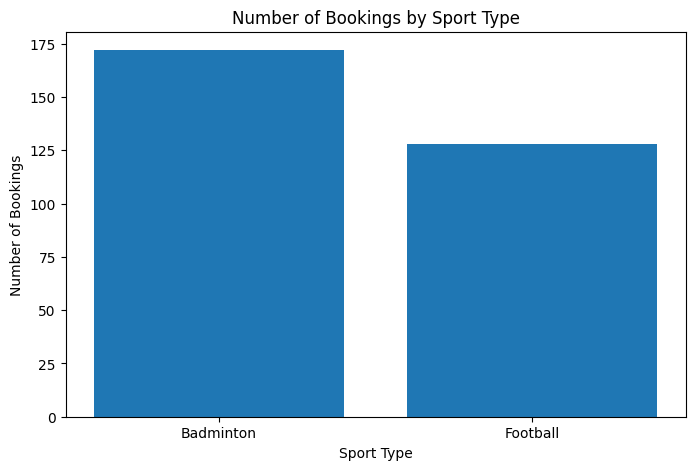

In [27]:
# ข้อ 27 สร้างกราฟแท่งแสดงจำนวนการจองแยกตามประเภทกีฬา

plt.figure(figsize=(8, 5))
# กำหนดขนาดของกราฟ
# ความกว้าง = 8 นิ้ว และความสูง = 5 นิ้ว

plt.bar(
    sport_summary["sport_type"],
    sport_summary["booking_count"]
)
# สร้างกราฟแท่ง (Bar Chart)
# แกน X ใช้ข้อมูลประเภทกีฬา (sport_type)
# แกน Y ใช้ข้อมูลจำนวนการจอง (booking_count)

plt.title(
    "Number of Bookings by Sport Type"
)
# กำหนดชื่อกราฟ
# หมายถึง "จำนวนการจองแยกตามประเภทกีฬา"

plt.xlabel(
    "Sport Type"
)
# กำหนดชื่อแกน X
# แกน X แสดงประเภทกีฬา เช่น ฟุตบอล หรือแบดมินตัน

plt.ylabel(
    "Number of Bookings"
)
# กำหนดชื่อแกน Y
# แกน Y แสดงจำนวนการจอง

plt.show()
# แสดงกราฟที่สร้างขึ้น

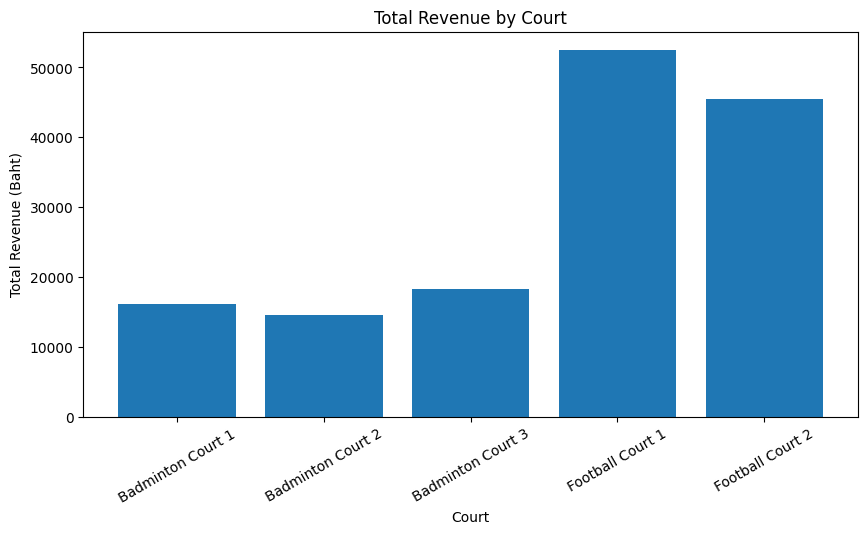

In [28]:
# ข้อ 28 สร้างกราฟแท่งแสดงรายได้รวมของแต่ละสนาม

plt.figure(figsize=(10, 5))
# กำหนดขนาดของกราฟ
# ความกว้าง = 10 นิ้ว และความสูง = 5 นิ้ว

plt.bar(
    court_summary["court_name"],
    court_summary["total_revenue"]
)
# สร้างกราฟแท่ง (Bar Chart)
# แกน X ใช้ชื่อสนาม (court_name)
# แกน Y ใช้รายได้รวมของสนาม (total_revenue)

plt.title(
    "Total Revenue by Court"
)
# กำหนดชื่อกราฟ
# หมายถึง "รายได้รวมของแต่ละสนาม"

plt.xlabel(
    "Court"
)
# กำหนดชื่อแกน X
# แกน X แสดงชื่อสนาม

plt.ylabel(
    "Total Revenue (Baht)"
)
# กำหนดชื่อแกน Y
# แกน Y แสดงรายได้รวม โดยหน่วยเป็นบาท

plt.xticks(rotation=30)
# หมุนชื่อสนามบนแกน X 30 องศา
# เพื่อให้ชื่อสนามอ่านง่ายและไม่ทับกัน

plt.show()
# แสดงกราฟ

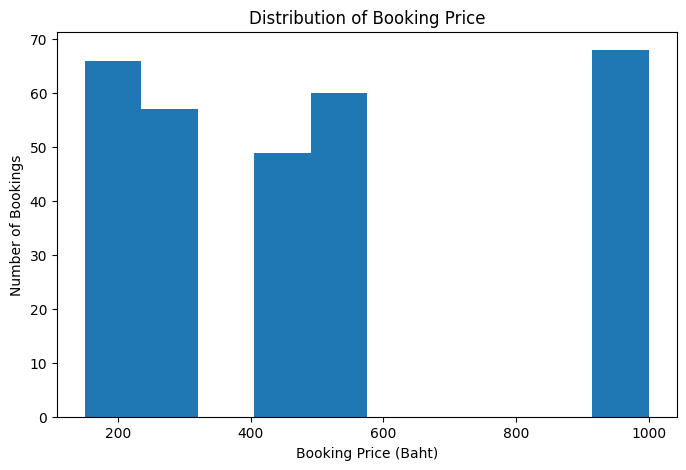

In [29]:
# ข้อ 29 สร้างกราฟ Histogram แสดงการกระจายของราคาการจอง

plt.figure(figsize=(8, 5))
# กำหนดขนาดของกราฟ
# ความกว้าง = 8 นิ้ว และความสูง = 5 นิ้ว

plt.hist(
    df["total_price"],
    bins=10
)
# สร้างกราฟ Histogram
# ใช้ข้อมูลราคาการจองจากคอลัมน์ total_price
# bins=10 แบ่งช่วงของราคาออกเป็น 10 ช่วง
# เพื่อดูว่าราคาการจองส่วนใหญ่อยู่ในช่วงไหน

plt.title(
    "Distribution of Booking Price"
)
# กำหนดชื่อกราฟ
# หมายถึง "การกระจายของราคาการจอง"

plt.xlabel(
    "Booking Price (Baht)"
)
# กำหนดชื่อแกน X
# แกน X แสดงราคาการจอง หน่วยเป็นบาท

plt.ylabel(
    "Number of Bookings"
)
# กำหนดชื่อแกน Y
# แกน Y แสดงจำนวนการจองในแต่ละช่วงราคา

plt.show()
# แสดงกราฟ

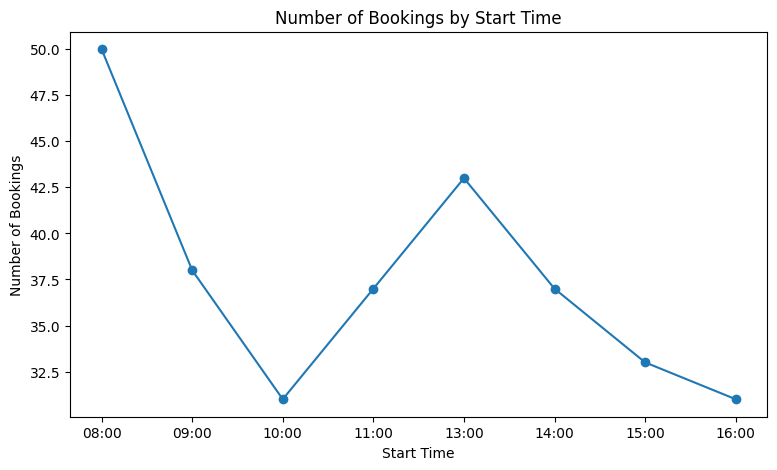

In [30]:
# ข้อ 30 สรุปจำนวนการจองตามเวลาเริ่มต้น และสร้างกราฟเส้น

time_summary = (
    df.groupby("start_time")
    # จัดกลุ่มข้อมูลตามเวลาเริ่มต้นการจอง
    # เช่น 08:00, 09:00, 10:00 เป็นต้น

    .agg(
        booking_count=(
            "booking_id",
            "count"
        )
    )
    # นับจำนวน booking_id ในแต่ละช่วงเวลา
    # เพื่อหาว่าแต่ละเวลา มีการจองทั้งหมดกี่รายการ

    .reset_index()
    # จัดรูปแบบ DataFrame ใหม่
    # ทำให้ start_time กลับมาเป็นคอลัมน์ปกติ
)

time_summary = time_summary.sort_values(
    "start_time"
)
# เรียงข้อมูลตามเวลาเริ่มต้นการจอง
# จากเวลาเริ่มต้นน้อยไปมาก


plt.figure(figsize=(9, 5))
# กำหนดขนาดของกราฟ
# ความกว้าง = 9 นิ้ว และความสูง = 5 นิ้ว


plt.plot(
    time_summary["start_time"],
    time_summary["booking_count"],
    marker="o"
)
# สร้างกราฟเส้น (Line Chart)
# แกน X = เวลาเริ่มต้นการจอง
# แกน Y = จำนวนการจอง
# marker="o" เพิ่มจุดวงกลมในแต่ละข้อมูล
# เพื่อให้เห็นค่าของแต่ละช่วงเวลาได้ชัดเจน


plt.title(
    "Number of Bookings by Start Time"
)
# กำหนดชื่อกราฟ
# หมายถึง "จำนวนการจองตามเวลาเริ่มต้น"


plt.xlabel(
    "Start Time"
)
# กำหนดชื่อแกน X
# แกน X แสดงเวลาเริ่มต้นการจอง


plt.ylabel(
    "Number of Bookings"
)
# กำหนดชื่อแกน Y
# แกน Y แสดงจำนวนการจอง


plt.show()
# แสดงกราฟ